<a href="https://colab.research.google.com/github/qjpbtuzara-ai/CPE311-CPE22S3/blob/main/Pair_7_Tuzara_Case_Study3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Tuzara, John Paul B. <br>
Course & Section: CPE311 - CPE22S3 <br>
Date: 4/16/26 <br>
Instructor: Engr. Neal Barton James Matira

#SDG: 8 Decent Jobs and Economic Growth

##Step 1
* We need to find out how rapidly ASEAN countries are adopting AI compared to the size of their unprotected workforce in order to determine if the digital "Mesh Economy" theory by Gansky is leaving informal workers behind and is threatening SDG 8.

##Step 2
* Does a country's AI Infrastructure outpace its social protections, compromising the social trust that puts the informal sector at risk of job displacement?

##Step 3
* The data can be found in the ASEAN stats portal for its SDG 8.3, in which the informal employment data for all sexes can be found.
* Meanwhile, the data for the AI governance index can be found via the Oxford insights.



#Supplementary
1. Map out your datasets to your described objective.
* I have succesfully mapped out the dataset along with ETL to generate 2 graphs of the dataset in order to prove the relationship of AI adoptin and workforce vulnerability.
2. Link and cite all your data.
* ASEAN Data Science Portal:
* https://data.aseanstats.org/sdg#
* OXford Insights:
* https://oxfordinsights.com/ai-readiness/government-ai-readiness-index-2025/
* Additional Resources:
* https://informationdj.wordpress.com/wp-content/uploads/2012/01/future-of-business-is-lisa-gansky.pdf

3. What do you aim to prove with your dataset and visualization?
* I am to prove how AI adoption affects the secuity of informal workers, partularly how AI will displace these unprotected workers as the social trust of gansky's mesh will break as the trend of  
4. What is the narrative you want to write based on your data?
* I want to write that based on the evidence, the "AI bubble" is becoming less and less and will soon be totally integrated to every economic sector.

In [2]:
#Extract
import pandas as pd
import numpy as np

ai_df = pd.read_excel('oxford_insights_asean_cleaned.xlsx')

sdg_df = pd.read_excel('sdg_extracted_data_214344.xlsx', na_values=['na', 'nap'])

sdg_df.columns = sdg_df.columns.astype(str)

years = ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
sdg_df['Latest_Informal_Rate'] = sdg_df[years].ffill(axis=1).iloc[:, -1]

vulnerability_data = sdg_df[['Country', 'Latest_Informal_Rate']]

df_master = pd.merge(ai_df, vulnerability_data, on='Country', how='inner')

df_master['Mesh_Resilience_Score'] = df_master['AI Infrastructure'] / df_master['Latest_Informal_Rate']

display(df_master.sort_values(by='Total Score', ascending=False))

--- ASEAN Regional AI & Vulnerability Table ---


,Ranking,Country,Total Score,AI Infrastructure,Governance,Public Sector Adoption,Latest_Informal_Rate,Mesh_Resilience_Score
0,7,Singapore,76.42,74.46,78.30,92.50,NaN,NaN
1,34,Thailand,63.22,56.38,70.44,85.86,34.70,1.624784
2,38,Malaysia,62.34,60.52,78.48,64.78,19.78,3.059656
3,43,Philippines,60.51,49.50,83.34,69.17,NaN,NaN
4,45,Viet Nam,59.98,57.41,88.05,73.21,54.20,1.059225
5,46,Indonesia,59.87,60.28,61.25,73.77,47.59,1.266653
6,97,Brunei Darussalam,40.51,47.39,35.06,65.14,10.40,4.556731
7,118,Cambodia,33.91,32.77,53.38,36.25,45.80,0.715502
8,125,Lao PDR,29.92,38.21,45.17,18.21,90.90,0.420352
9,173,Myanmar,20.54,33.25,13.67,12.32,85.20,0.390258



Success! The merged data has been saved as 'ADSE_Regional_Master.csv'.


In [4]:
#Transform
df_master = pd.read_csv('ADSE_Regional_Master.csv')

df_master.loc[df_master['Country'] == 'Singapore', 'Latest_Informal_Rate'] = df_master.loc[df_master['Country'] == 'Singapore', 'Latest_Informal_Rate'].fillna(1.0)

df_master.loc[df_master['Country'] == 'Philippines', 'Latest_Informal_Rate'] = df_master.loc[df_master['Country'] == 'Philippines', 'Latest_Informal_Rate'].fillna(42.0)
df_master.loc[df_master['Country'] == 'Brunei Darussalam', 'Latest_Informal_Rate'] = 37.9

df_master['Latest_Informal_Rate'] = pd.to_numeric(df_master['Latest_Informal_Rate'], errors='coerce')

df_master['Mesh_Resilience_Score'] = df_master['AI Infrastructure'] / df_master['Latest_Informal_Rate']

display(df_master.sort_values(by='Total Score', ascending=False))
df_master.to_csv('ADSE_Regional_Master_Cleaned.csv', index=False)

,Ranking,Country,Total Score,AI Infrastructure,Governance,Public Sector Adoption,Latest_Informal_Rate,Mesh_Resilience_Score
0,7,Singapore,76.42,74.46,78.30,92.50,1.00,74.460000
1,34,Thailand,63.22,56.38,70.44,85.86,34.70,1.624784
2,38,Malaysia,62.34,60.52,78.48,64.78,19.78,3.059656
3,43,Philippines,60.51,49.50,83.34,69.17,42.00,1.178571
4,45,Viet Nam,59.98,57.41,88.05,73.21,54.20,1.059225
5,46,Indonesia,59.87,60.28,61.25,73.77,47.59,1.266653
6,97,Brunei Darussalam,40.51,47.39,35.06,65.14,10.40,4.556731
7,118,Cambodia,33.91,32.77,53.38,36.25,45.80,0.715502
8,125,Lao PDR,29.92,38.21,45.17,18.21,90.90,0.420352
9,173,Myanmar,20.54,33.25,13.67,12.32,85.20,0.390258


###Step 4 Visualize

             Country  AI Infrastructure  Latest_Informal_Rate
0          Singapore              74.46                  1.00
2           Malaysia              60.52                 19.78
5          Indonesia              60.28                 47.59
4           Viet Nam              57.41                 54.20
1           Thailand              56.38                 34.70
3        Philippines              49.50                 42.00
6  Brunei Darussalam              47.39                 10.40
8            Lao PDR              38.21                 90.90
9            Myanmar              33.25                 85.20
7           Cambodia              32.77                 45.80


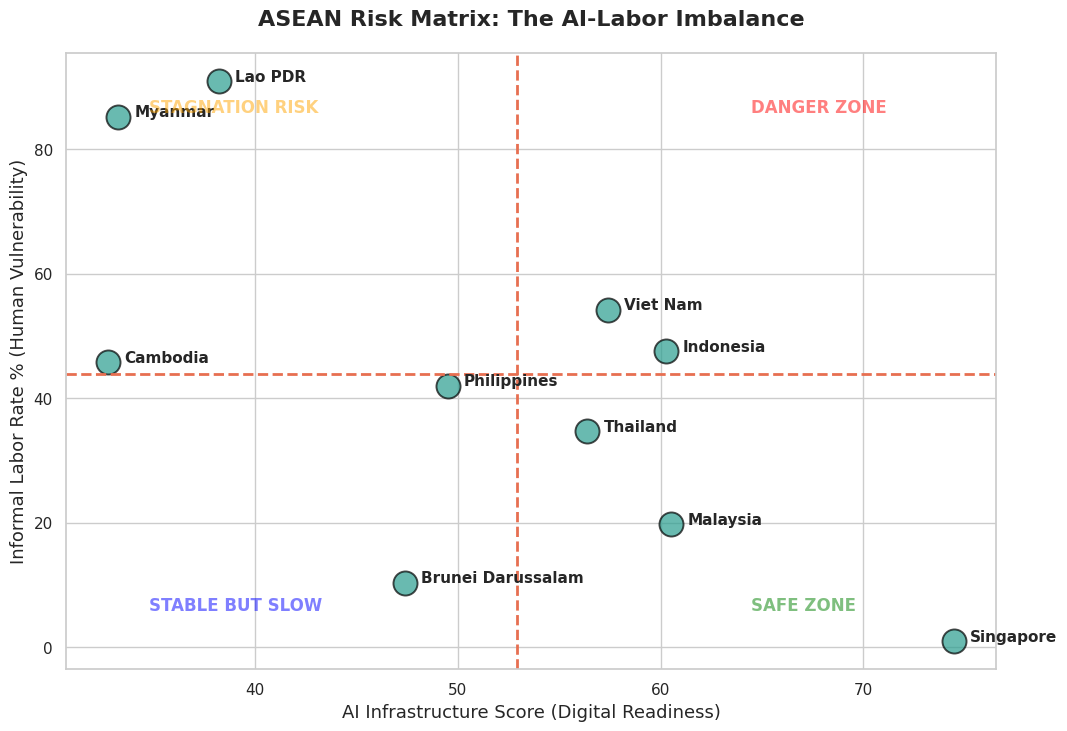

In [9]:
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df,
    x='AI Infrastructure',
    y='Latest_Informal_Rate',
    s=300,
    color='#2a9d8f',
    edgecolor='black',
    alpha=0.7
)

for i in range(df.shape[0]):
    plt.text(
        df['AI Infrastructure'][i] + 0.8,
        df['Latest_Informal_Rate'][i],
        df['Country'][i],
        fontsize=11,
        weight='bold'
    )

x_mid = df['AI Infrastructure'].median()
y_mid = df['Latest_Informal_Rate'].median()

plt.axvline(x_mid, color='#e76f51', linestyle='--', linewidth=2, label='Median Infrastructure')
plt.axhline(y_mid, color='#e76f51', linestyle='--', linewidth=2, label='Median Vulnerability')

plt.title('ASEAN Risk Matrix: The AI-Labor Imbalance', fontsize=16, weight='bold', pad=20)
plt.xlabel('AI Infrastructure Score (Digital Readiness)', fontsize=13)
plt.ylabel('Informal Labor Rate % (Human Vulnerability)', fontsize=13)

plt.text(df['AI Infrastructure'].max()-10, df['Latest_Informal_Rate'].min()+5, "SAFE ZONE", color='green', weight='bold', fontsize=12, alpha=0.5)
plt.text(df['AI Infrastructure'].max()-10, df['Latest_Informal_Rate'].max()-5, "DANGER ZONE", color='red', weight='bold', fontsize=12, alpha=0.5)
plt.text(df['AI Infrastructure'].min()+2, df['Latest_Informal_Rate'].max()-5, "STAGNATION RISK", color='orange', weight='bold', fontsize=12, alpha=0.5)
plt.text(df['AI Infrastructure'].min()+2, df['Latest_Informal_Rate'].min()+5, "STABLE BUT SLOW", color='blue', weight='bold', fontsize=12, alpha=0.5)

print(df[['Country', 'AI Infrastructure', 'Latest_Informal_Rate']].sort_values(by='AI Infrastructure', ascending=False))

Data Analysis
There is a huge gap in labor resilience in ASEAN, Vietnam and Indonesia have a rising tech industry yet they are subject to risk during an AI transition trend especially as we move into the AI bubble. Ironically, they are the countries that need AI the most.


/tmp/ipykernel_530/3639563885.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


             Country  Mesh_Resilience_Score
0          Singapore              74.460000
1  Brunei Darussalam               4.556731
2           Malaysia               3.059656
3           Thailand               1.624784
4          Indonesia               1.266653
5        Philippines               1.178571
6           Viet Nam               1.059225
7           Cambodia               0.715502
8            Lao PDR               0.420352
9            Myanmar               0.390258


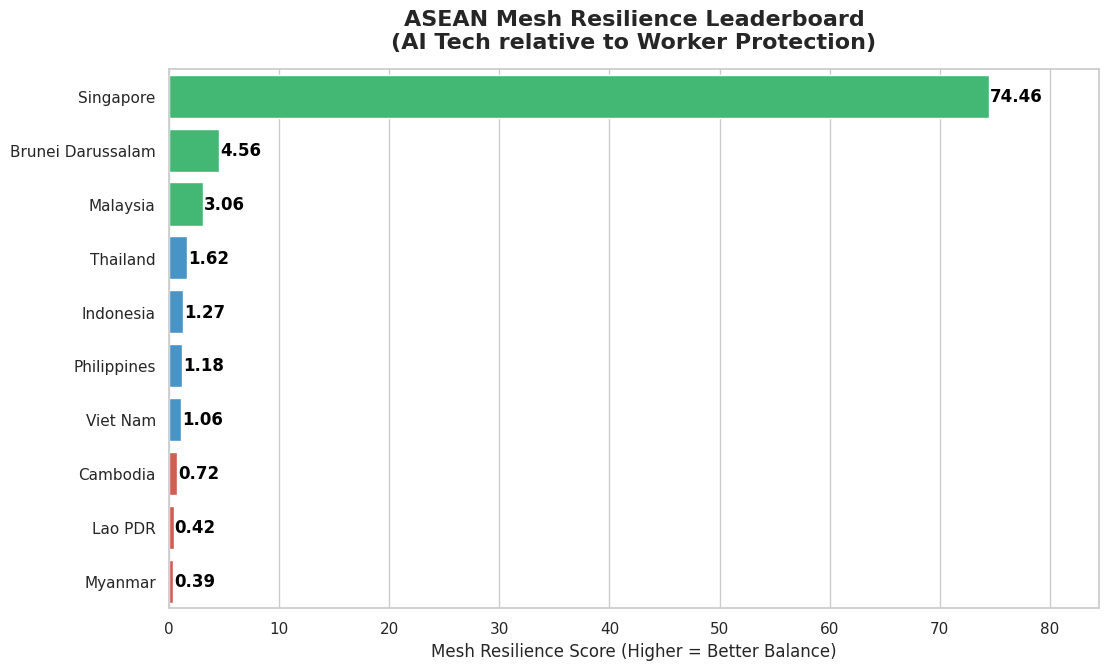

In [7]:
df_sorted = df.sort_values('Mesh_Resilience_Score', ascending=False).reset_index(drop=True)
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

colors = ['#2ECC71' if x > 2 else '#E74C3C' if x < 1 else '#3498DB' for x in df_sorted['Mesh_Resilience_Score']]

ax = sns.barplot(
    data=df_sorted,
    x='Mesh_Resilience_Score',
    y='Country',
    palette=colors
)

for i, v in enumerate(df_sorted['Mesh_Resilience_Score']):
    ax.text(v + 0.1, i, f"{v:.2f}", color='black', va='center', fontweight='bold')

plt.title('ASEAN Mesh Resilience Leaderboard\n(AI Tech relative to Worker Protection)', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Mesh Resilience Score (Higher = Better Balance)', fontsize=12)
plt.ylabel('')
plt.xlim(0, df_sorted['Mesh_Resilience_Score'].max() + 10)

plt.savefig('Mesh_Resilience_Leaderboard.png', bbox_inches='tight', dpi=300)
print(df_sorted[['Country', 'Mesh_Resilience_Score']])

###Data Analysis
Since Singapore has high tech and practically no informal labor. Which tells me that a lower informal labor rate leads to a higher Mesh resilience. Countries on the bottom half coulf invest more on formalizing their workforce.

#Conclusions and Analysis

In conclusion, AI adoption makes countries' unprotected and unsecured workforce very vulnerable to AI. Tech adoption does not simply make it a solution from AI adoption, even if the countries that need it most to make other sectors of their economy optimal, they are still at risk. ASEAN's rapid adoption of AI is unbalanced as of now as countries like Vietnam and Indonesia are succesfully building AI infrastructure, their labor markets remain at risk as informal. Gansky's social trust imbalance means millions of workers without contracts or safety nets are immedietely risks of displacement. The wealth generated across ASEAN members through AI will be unequal as Singapore's is currently 74 times that of the lowest by comparison. These nations face a future of increased inequality rather than Decent Work, there should be coordinated regional effort to formalize labor markets as Dansky's "Access over Ownership" needs to be accounted as a shift towards before adopting a large scale AI adoption.

